<a href="https://colab.research.google.com/github/gsferreira-tec/vcomp/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1

### Authors

- Guilherme Sousa Ferreira - **Student ID**: up201706719
- Diogo Loayza Duarte - **Student ID**: up2021...
---


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

from pathlib import Path
# Setup the relevant directory/subdirectories for the assignment
root_dir = Path('/content/drive/MyDrive/VCOMP/Assignment-1')
calib_dir = root_dir/'Calibration'
fault_dir = root_dir/'Faults'
isolated_dir = root_dir/'Isolated'
kit_dir = root_dir/'Kit'


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## ***Task 1 - "Calibration Images"***
## **a)**
 - We are asked to present the intrinsic matrix, the lens distortion coefficients and the re-projection error.
 - Afterwards we select the best calibration and justify the selection with 2 sentences.
---

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import glob2 # used to get all the images in a directory path into a list

# define paths to calibration folders
calib_1 = calib_dir/'calib1'
calib_2 = calib_dir/'calib2'
calib_3 = calib_dir/'calib3'

# build a function to go through all the calib directories and the images within and extract the metrics asked
# - Intrinsic Matrix
# - Lens distortion coefficients
# - Re-projection error
def parameter_extraction(directory, checkerboard_size=(11,8), square_size=15):
    image_list = list(directory.glob('*.png')) # get all the from the path provided (calib1, calib2, calib3, ...)
    #if needed we could format the images to have the same formatting(jpeg, png, etc.)

    # ---- DEBUG ----
    if len(image_list) == 0:
        print("Something went wrong. The image list is empty.\n")
        return None, None, None

    # in order to know if the calibration is correct we must create a prediction/model for what the correct checkerboard should be
    # this should be especcially important to measure the lens distortion by comparing that with the modeled "tr uth"
    objp = np.zeros((checkerboard_size[0] * checkerboard_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:checkerboard_size[0], 0:checkerboard_size[1]].T.reshape(-1,2) * square_size

    # lists to store corresponding object point and image points
    objpoints = []
    imgpoints = []

    for image in image_list:
        img_bgr = cv2.imread(str(image)) # read the image

        # for computational efficiency and accuracy we will work with grayscale image
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        # after reading we find the corners
        ret, corners = cv2.findChessboardCorners(img_gray, checkerboard_size, None)

        # ret==True means that findChessboardCorners was successfull and therefore we can append the corners to a list with the object points used (objp) and the correponding "corners" (image_points) to use (2D projection)
        if ret == True:
            objpoints.append(objp)
            imgpoints.append(corners)

    # calling this function returns the metrics we need to display
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, img_gray.shape[::-1], None, None)

    # return the re-projecyion error, the intrinsic matrix and the lens DISTortion coefficients, respetively
    return ret, mtx, dist

# Next step we use the function to determine these parameters for every calibration attempt and display them
ret_1, mtx_1, dist_1 = parameter_extraction(calib_1)
ret_2, mtx_2, dist_2 = parameter_extraction(calib_2)
ret_3, mtx_3, dist_3 = parameter_extraction(calib_3)

# displaying the results
results = [
    ("CALIBRATION 1", ret_1, mtx_1, dist_1),
    ("CALIBRATION 2", ret_2, mtx_2, dist_2),
    ("CALIBRATION 3", ret_3, mtx_3, dist_3)
]

for name, ret, mtx, dist in results:
    if ret is not None:
        print(f"**** {name} ****")
        print(f"Re-Projection Error: {ret:.4f}\n")
        print(f"Intrinsic Matrix:\n{np.round(mtx,2)}\n")
        print(f"Lens Distortion: {np.round(dist.ravel(), 4)}\n")
    else:
        print(f"**** {name} **** FAILED!")

**** CALIBRATION 1 ****
Re-Projection Error: 0.3315

Intrinsic Matrix:
[[836.79   0.   342.87]
 [  0.   837.   281.47]
 [  0.     0.     1.  ]]

Lens Distortion: [-4.246e-01  3.059e-01 -1.100e-03  1.000e-04 -3.226e-01]

**** CALIBRATION 2 ****
Re-Projection Error: 0.6156

Intrinsic Matrix:
[[846.79   0.   346.94]
 [  0.   847.14 277.27]
 [  0.     0.     1.  ]]

Lens Distortion: [-0.4326  0.2551  0.0005 -0.0017  0.0133]

**** CALIBRATION 3 ****
Re-Projection Error: 0.6838

Intrinsic Matrix:
[[837.9    0.   340.52]
 [  0.   838.32 276.98]
 [  0.     0.     1.  ]]

Lens Distortion: [-4.098e-01  1.841e-01 -3.000e-04  1.000e-04  7.240e-02]



**Answer:**
- Analysing the results of the three calibration attempts we can safely say that the attempt that yielded the best results was **Calibration 1**.

**Justification:**

- In comparison to the others, calibration 1 has by far the lowest re-projection error (0.3315 compared to 0.6156 or 0.6838).
- This means that the values determined for the **Intrinsic Matrix** and the **Lens Distortion Coefficients**, in calibration 1, add up to a better representation of the limitations of the camera which in turn allow us to compensate for those imperfections with much better accuracy.

---
## **b)**
- "final_setup.png" represents the final inspection arrangement. Calibrate the extrinsic parameters of the camera setup. Present the extrinsic matrix and specify the pixel-to-milimeter conversion factor applied.

In [ ]:
"""
After a prompt in Gemini I find that the function that allows the computation of the extrinsic parameter matrix is the function in OpenCV called solvePnP
or solve Perpective-n-Point.

This function will allow us to determine the parameters that delineate the physical position of the camera relative to the table.

It takes as arguments object points model created in the previous step, the corners of the final_setup.png image which also have to be determined
and the parameters of the imperfections determined for the calibration selected (mtx_1 and dist_1).
"""

# path of the final_setup image
img_path = calib_dir
final_setup_img = cv2.imread(str(img_path/'final_setup.png'))

# convert to gray scale for the same reason as previously stated
gray_setup_img = cv2.cvtColor(final_setup_img, cv2.COLOR_BGR2GRAY)

# build the checkerboard's "true" model
checkerboard_size=(11,8)
square_size = 15
objp = np.zeros((checkerboard_size[0] * checkerboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:checkerboard_size[0], 0:checkerboard_size[1]].T.reshape(-1,2) * square_size

# lists to store corresponding object point and image points
objpoints = []
imgpoints = []

# determine the corners for the image
ret, final_corners = cv2.findChessboardCorners(gray_setup_img, checkerboard_size, None)

if ret == True:
    # determine the extrinsic parameters/matrix
    ret_2, rvec, tvec = cv2.solvePnP(objp, final_corners, mtx_1, dist_1)

    R_matrix , _ = cv2.Rodrigues(rvec)
    ext_mtx = np.hstack((R_matrix, tvec))

    print("Extrinsic Matrix:\n", np.round(ext_mtx, 3))
else:
    print("No corners were found in the image...\n")

Extrinsic Matrix:
 [[-9.98000e-01 -1.20000e-02 -5.90000e-02  6.30500e+01]
 [ 9.00000e-03 -9.98000e-01  6.00000e-02  3.40230e+01]
 [-5.90000e-02  6.00000e-02  9.96000e-01  2.66468e+02]]


In [ ]:
"""
Now to determine the pixel to mm conversion ratio used we can apply the euclidian distance formula to figure out the distance between pixels and then compare
that with the actual distance used which is given as 15mm.
"""

# determining 2 points
corner_point_1 = final_corners[0][0]
corner_point_2 = final_corners[1][0]

# determine the distance between these 2 point using numpy
pxl_distance = np.linalg.norm(corner_point_1-corner_point_2)

# determine the conversion ratio
conversion_ratio = 15/pxl_distance

# display the ratio used
print(f"Conversion Factor: {conversion_ratio:.4f}\n")

Conversion Factor: 0.3453



## ***Task 2 - "Isolated Brick Images"***
## **a)**
- Define an ROI for the image.

ROI 1 : x = 289.0000; y = 322.0000; width = 136.0000; height = 136.0000.
ROI 2 : x = 88.0000; y = 310.0000; width = 152.0000; height = 170.0000.
ROI 3 : x = 443.0000; y = 235.0000; width = 149.0000; height = 131.0000.
ROI 4 : x = 376.0000; y = 140.0000; width = 67.0000; height = 112.0000.
ROI 5 : x = 192.0000; y = 133.0000; width = 141.0000; height = 140.0000.
ROI 6 : x = 7.0000; y = 95.0000; width = 118.0000; height = 209.0000.
ROI 7 : x = 480.0000; y = 67.0000; width = 126.0000; height = 130.0000.
ROI 8 : x = 137.0000; y = 12.0000; width = 293.0000; height = 99.0000.


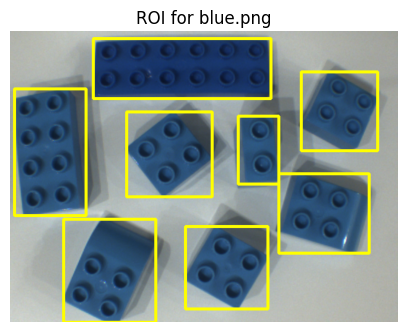

ROI 1 : x = 206.0000; y = 290.0000; width = 290.0000; height = 190.0000.
ROI 2 : x = 59.0000; y = 187.0000; width = 252.0000; height = 189.0000.
ROI 3 : x = 366.0000; y = 107.0000; width = 205.0000; height = 191.0000.
ROI 4 : x = 13.0000; y = 67.0000; width = 213.0000; height = 149.0000.
ROI 5 : x = 279.0000; y = 14.0000; width = 114.0000; height = 115.0000.


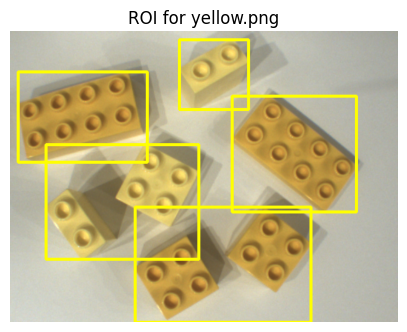

ROI 1 : x = 244.0000; y = 323.0000; width = 129.0000; height = 129.0000.
ROI 2 : x = 429.0000; y = 165.0000; width = 201.0000; height = 207.0000.
ROI 3 : x = 269.0000; y = 136.0000; width = 111.0000; height = 111.0000.
ROI 4 : x = 62.0000; y = 97.0000; width = 137.0000; height = 137.0000.
ROI 5 : x = 358.0000; y = 10.0000; width = 112.0000; height = 113.0000.


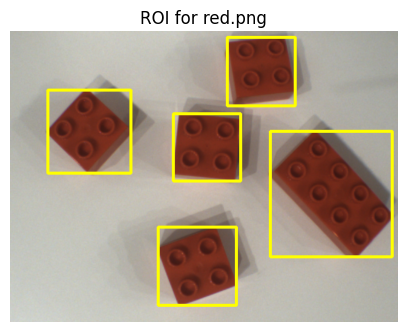

ROI 1 : x = 165.0000; y = 353.0000; width = 102.0000; height = 101.0000.
ROI 2 : x = 334.0000; y = 300.0000; width = 118.0000; height = 116.0000.
ROI 3 : x = 416.0000; y = 159.0000; width = 117.0000; height = 111.0000.
ROI 4 : x = 64.0000; y = 117.0000; width = 212.0000; height = 153.0000.
ROI 5 : x = 241.0000; y = 23.0000; width = 131.0000; height = 131.0000.
ROI 6 : x = 419.0000; y = 11.0000; width = 105.0000; height = 111.0000.


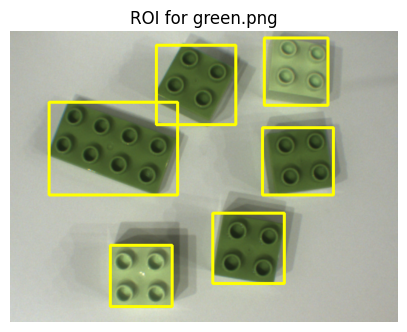

ROI 1 : x = 231.0000; y = 335.0000; width = 124.0000; height = 123.0000.
ROI 2 : x = 395.0000; y = 316.0000; width = 112.0000; height = 114.0000.
ROI 3 : x = 373.0000; y = 158.0000; width = 241.0000; height = 142.0000.
ROI 4 : x = 520.0000; y = 40.0000; width = 108.0000; height = 117.0000.
ROI 5 : x = 392.0000; y = 26.0000; width = 110.0000; height = 116.0000.
ROI 6 : x = 0.0000; y = 9.0000; width = 341.0000; height = 330.0000.


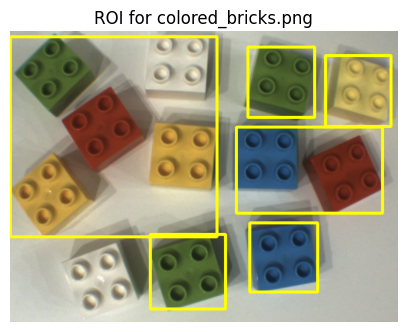

In [ ]:
"""
Taking a look at the images we notice that using a single ROI for all of them is not feasible since the bricks are positioned in different positions and they are also different
amounts and sizes...

Since this is the case we must create an ROI for each image (and each brick) and for this we create the following function.
"""

def determine_roi(directory):
    #define the image list
    image_list = list(directory.glob('*.png'))

    # ---- DEBUG ----
    if len(image_list) == 0:
        print("Something went wrong. The image list is empty.\n")
        return None, None, None

    # convert the images to Grayscale from computational efficiency
    for img_path in image_list:
        img = cv2.imread(str(img_path))
        img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # for matplotlib only...

        # determine the HSV image parameters
        h, s, v = cv2.split(img_hsv)

        # blur the sat channel of the image to ignore very fine details
        blurred = cv2.GaussianBlur(s, (7, 7), 0)

        # determine the mask + optimal threshold for the image
        _ , mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # close the gaps in the mask
        kernel = np.ones((11,11), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # Cleaning some noise in the img
        noise_kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, noise_kernel)

        # compute the contours
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for i, contour in enumerate(contours):
            x, y, w, h = cv2.boundingRect(contour)

            if (w * h) > 3000:
                # display the ROi dimensions
                print(f"ROI {i+1} : x = {x:.4f}; y = {y:.4f}; width = {w:.4f}; height = {h:.4f}.")
                # draw the ROI on the image
                cv2.rectangle(img_rgb, (x,y), (x+w, y+h), color=(255,255,0), thickness=3)

        # Display the ROI for each image
        plt.figure(figsize=(5,5))
        plt.imshow(img_rgb)
        plt.title(f"ROI for {img_path.name}")
        plt.axis("off")
        plt.show()

# call the function
determine_roi(isolated_dir)


## **b)**
- For image "colored_bricks.png", count the number of bricks grouped by color.



| Size | Avg Area (pixel)| Avg Area (mm) | Std Deviation (mm) |
|------|-----------------|---------------|--------------------|
| 2x1  |                 |               |                    |
| 2x2  |                 |               |                    |
| 2x4  |                 |               |                    |
| 2x6  |                 |               |                    |
| R2x2 |                 |               |                    |